In [98]:
import pandas as pd

In [99]:
df = pd.read_csv('Restaurant_Reviews.tsv', sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [100]:
df.shape

(1000, 2)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  1000 non-null   str  
 1   Liked   1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB


In [102]:
# 1. Calculate null sum
count_null = df.isnull().sum()

# 2. Transform into a DataFrame and rename columns
df_nulls = count_null.reset_index()
df_nulls.columns = ['Column', 'Null_Count']

# 3. Add percentage column for quick analysis
df_nulls['Percentage (%)'] = (df_nulls['Null_Count'] / len(df)) * 100

# Sort by most nulls
df_nulls = df_nulls.sort_values(by='Null_Count', ascending=False)

df_nulls

,Column,Null_Count,Percentage (%)
0,Review,0,0.0
1,Liked,0,0.0


In [103]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import layers

# --- PRE-CLEANING (Important to avoid conversion errors) ---
# Ensure no null values exist and force everything to string type
df['Review'] = df['Review'].fillna('').astype(str)

# 1. Preparing Labels (Restaurant Ratings)
le = LabelEncoder()
y = le.fit_transform(df['Liked']) 
num_classes = len(le.classes_)

# 2. Splitting the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df['Review'], y, test_size=0.2, random_state=42
)

# --- DTYPE CORRECTION: Converting to String Tensors ---
# This ensures TensorFlow recognizes the input as a valid string array
X_train_tensor = tf.convert_to_tensor(X_train.values, dtype=tf.string)
X_test_tensor = tf.convert_to_tensor(X_test.values, dtype=tf.string)

# 3. Text Vectorization Layer (Converts words to integers)
max_tokens = 10000 
sequence_length = 100 

vectorize_layer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)
# Adapt the layer using the training string tensor
vectorize_layer.adapt(X_train_tensor)

# 4. Neural Network Architecture (CPU-friendly for i5 processors)
model = tf.keras.Sequential([
    vectorize_layer,
    layers.Embedding(max_tokens, 32, mask_zero=True),
    layers.GlobalAveragePooling1D(), # Reduces complexity for faster CPU training
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2), # Helps prevent overfitting
    layers.Dense(num_classes, activation='softmax') # Final decision layer
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Training (Using the corrected tensors) - Capturing history for visualization
history = model.fit(
    X_train_tensor, 
    y_train, 
    epochs=7, 
    validation_data=(X_test_tensor, y_test), 
    batch_size=32
)

Epoch 1/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5962 - loss: 0.6913 - val_accuracy: 0.6450 - val_loss: 0.6896
Epoch 2/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7287 - loss: 0.6785 - val_accuracy: 0.6250 - val_loss: 0.6779
Epoch 3/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8363 - loss: 0.6386 - val_accuracy: 0.7400 - val_loss: 0.6457
Epoch 4/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8813 - loss: 0.5488 - val_accuracy: 0.7500 - val_loss: 0.5897
Epoch 5/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9225 - loss: 0.4184 - val_accuracy: 0.7700 - val_loss: 0.5276
Epoch 6/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9638 - loss: 0.2899 - val_accuracy: 0.7850 - val_loss: 0.4827
Epoch 7/7
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.1932 - val_accuracy: 0.8100 - val_loss: 0.4719


In [104]:
import numpy as np

In [105]:
# Model evaluation
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test_tensor, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_pred_probs = model.predict(X_test_tensor[:100], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Show sample predictions
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for i in range(10):
    predicted_rating = le.inverse_transform([y_pred[i]])[0]
    actual_rating = le.inverse_transform([y_test[i]])[0]
    confidence = y_pred_probs[i][y_pred[i]]
    
    print(f"\n--- Review {i+1} ---")
    print(f"Review Text: {X_test.iloc[i][:150]}...")
    print(f"Predicted Rating: {predicted_rating} (Confidence: {confidence*100:.2f}%)")
    print(f"Actual Rating: {actual_rating}")
    print(f"Result: {'✓ Correct' if predicted_rating == actual_rating else '✗ Incorrect'}")

MODEL EVALUATION

Test Loss: 0.4719
Test Accuracy: 0.8100 (81.00%)

SAMPLE PREDICTIONS

--- Review 1 ---
Review Text: If you haven't gone here GO NOW!...
Predicted Rating: 1 (Confidence: 57.68%)
Actual Rating: 1
Result: ✓ Correct

--- Review 2 ---
Review Text: Try them in the airport to experience some tasty food and speedy, friendly service....
Predicted Rating: 1 (Confidence: 85.39%)
Actual Rating: 1
Result: ✓ Correct

--- Review 3 ---
Review Text: The restaurant is very clean and has a family restaurant feel to it....
Predicted Rating: 1 (Confidence: 87.06%)
Actual Rating: 1
Result: ✓ Correct

--- Review 4 ---
Review Text: I personally love the hummus, pita, baklava, falafels and Baba Ganoush (it's amazing what they do with eggplant!)....
Predicted Rating: 1 (Confidence: 86.98%)
Actual Rating: 1
Result: ✓ Correct

--- Review 5 ---
Review Text: Come hungry, leave happy and stuffed!...
Predicted Rating: 1 (Confidence: 84.76%)
Actual Rating: 1
Result: ✓ Correct

--- Review 6 ---
Review

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

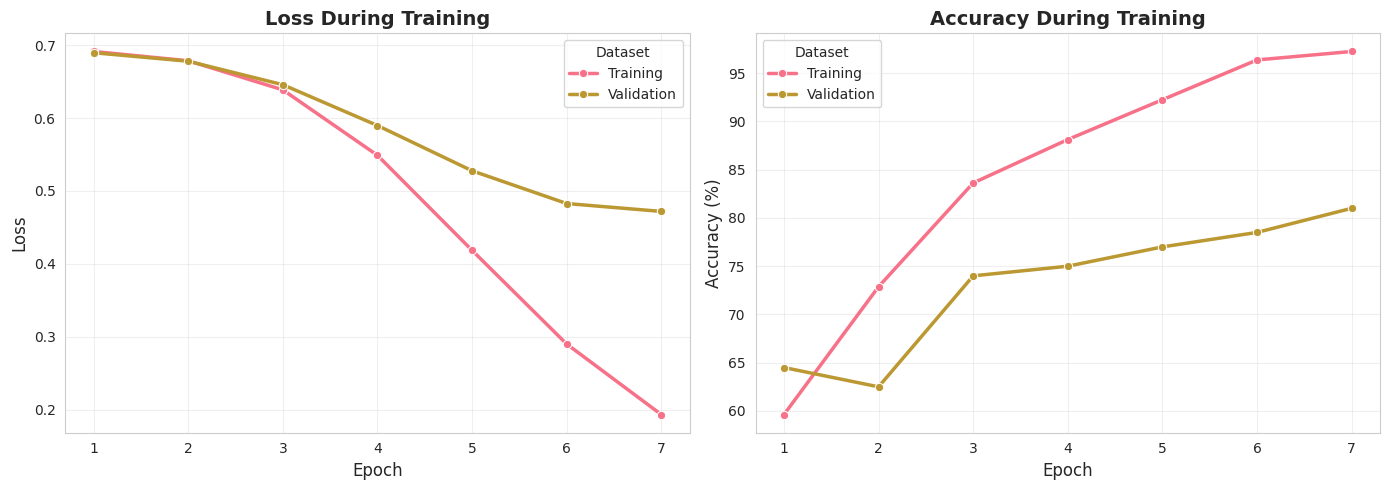


TRAINING SUMMARY

Initial Loss:      0.6913
Final Loss:        0.1932
Reduction:         72.05%

Initial Accuracy:  59.62%
Final Accuracy:    97.25%
Improvement:       37.63%

Validation Accuracy: 81.00%


In [107]:
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert history to DataFrame for Seaborn usage
history_df = pd.DataFrame(history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['loss'],
    'Type': 'Training'
})
val_loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['val_loss'],
    'Type': 'Validation'
})
combined_loss = pd.concat([loss_data, val_loss_data], ignore_index=True)

sns.lineplot(data=combined_loss, x='Epoch', y='Loss', hue='Type', 
             ax=axes[0], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Dataset')

# Plot 2: Accuracy
acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['accuracy'] * 100,
    'Type': 'Training'
})
val_acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['val_accuracy'] * 100,
    'Type': 'Validation'
})
combined_acc = pd.concat([acc_data, val_acc_data], ignore_index=True)

sns.lineplot(data=combined_acc, x='Epoch', y='Accuracy', hue='Type', 
             ax=axes[1], linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Dataset')

plt.tight_layout()
plt.show()

# Training summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"\nInitial Loss:      {history.history['loss'][0]:.4f}")
print(f"Final Loss:        {history.history['loss'][-1]:.4f}")
print(f"Reduction:         {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")

print(f"\nInitial Accuracy:  {history.history['accuracy'][0]*100:.2f}%")
print(f"Final Accuracy:    {history.history['accuracy'][-1]*100:.2f}%")
print(f"Improvement:       {(history.history['accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%")

print(f"\nValidation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 80)

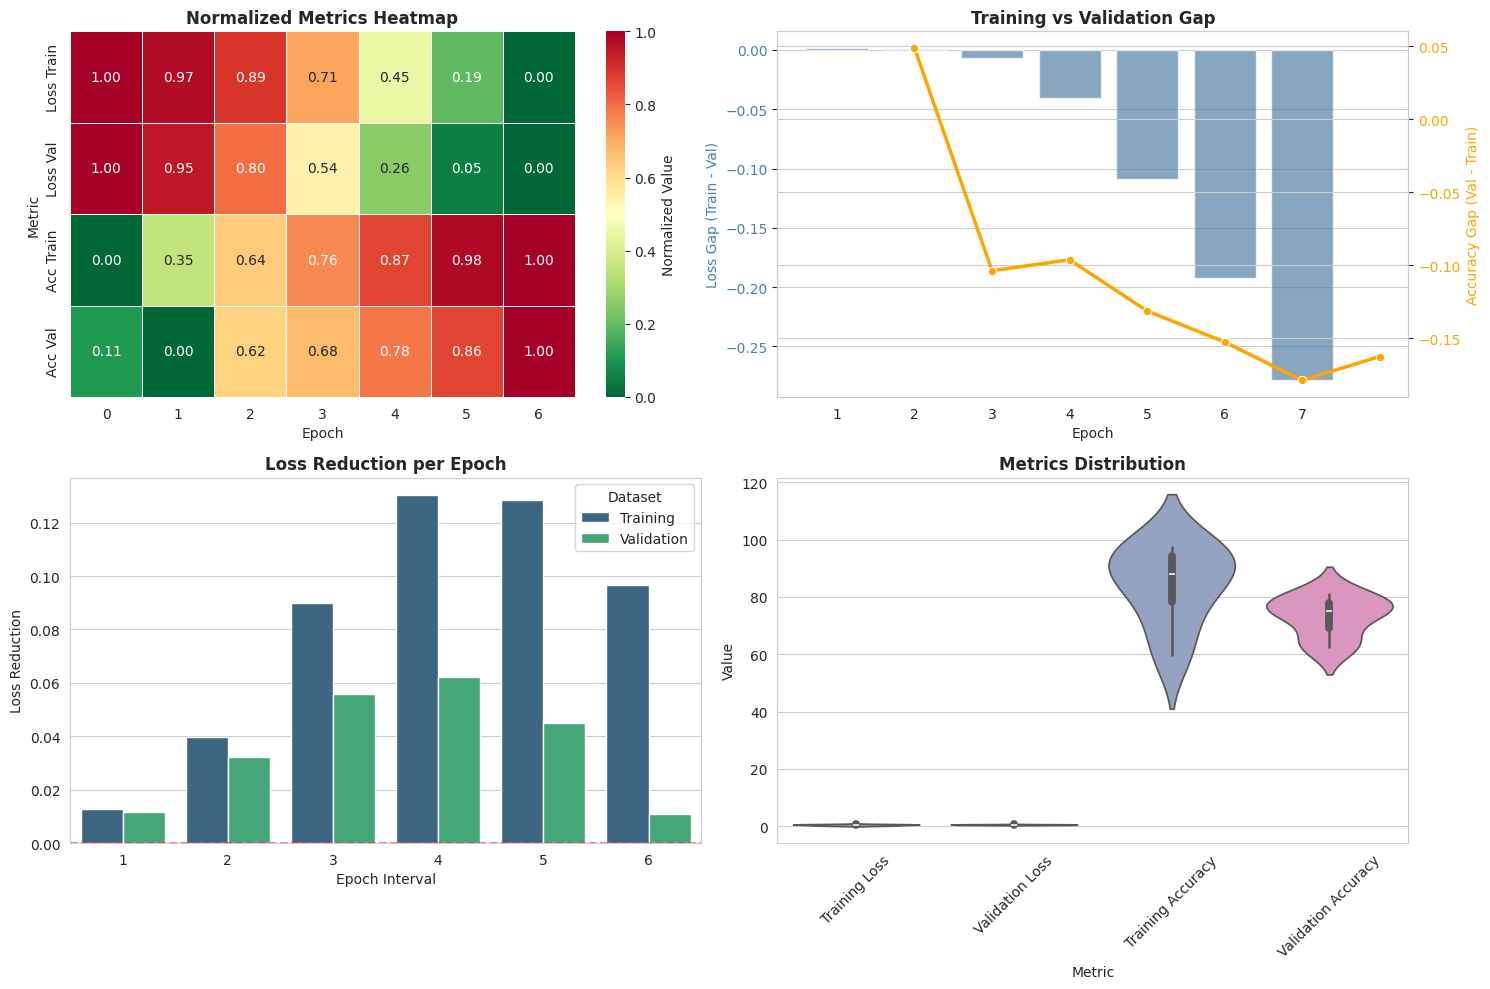


OVERFITTING ANALYSIS

Average Loss Gap (Train - Val): -0.0895
Final Loss Gap: -0.2787

Average Accuracy Gap (Val - Train): -11.09%
Final Accuracy Gap: -16.25%

✓ Well-balanced model (Low overfitting)


In [108]:
# Create figure with additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Metrics Heatmap
metrics_data = history_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].copy()
metrics_data.columns = ['Loss Train', 'Loss Val', 'Acc Train', 'Acc Val']
# Normalize for better visualization
metrics_normalized = (metrics_data - metrics_data.min()) / (metrics_data.max() - metrics_data.min())

sns.heatmap(metrics_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Normalized Value'}, ax=axes[0, 0], linewidths=0.5)
axes[0, 0].set_title('Normalized Metrics Heatmap', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Metric')

# Plot 2: Training vs Validation Gap
gap_loss = history_df['loss'] - history_df['val_loss']
gap_acc = history_df['val_accuracy'] - history_df['accuracy']

gap_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss Gap': gap_loss,
    'Acc Gap': gap_acc
})

ax2_twin = axes[0, 1].twinx()
sns.barplot(data=gap_data, x='Epoch', y='Loss Gap', ax=axes[0, 1], color='steelblue', alpha=0.7)
sns.lineplot(data=gap_data, x='Epoch', y='Acc Gap', ax=ax2_twin, color='orange', linewidth=2.5, marker='o')

axes[0, 1].set_title('Training vs Validation Gap', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Loss Gap (Train - Val)', color='steelblue', fontsize=10)
ax2_twin.set_ylabel('Accuracy Gap (Val - Train)', color='orange', fontsize=10)
axes[0, 1].tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='orange')

# Plot 3: Loss Reduction Speed
train_loss_diff = -np.diff(history_df['loss'])
val_loss_diff = -np.diff(history_df['val_loss'])
epochs = list(range(1, len(train_loss_diff) + 1))

# Create a "long-format" DataFrame for Seaborn
diff_data = pd.DataFrame({
    'Epoch_Interval': epochs * 2,
    'Loss_Reduction': np.concatenate([train_loss_diff, val_loss_diff]),
    'Dataset': ['Training'] * len(train_loss_diff) + ['Validation'] * len(val_loss_diff)
})

sns.barplot(
    data=diff_data, 
    x='Epoch_Interval', 
    y='Loss_Reduction', 
    hue='Dataset', 
    ax=axes[1, 0], 
    palette='viridis'
)

axes[1, 0].set_title('Loss Reduction per Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch Interval')
axes[1, 0].set_ylabel('Loss Reduction')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Plot 4: Metric Distribution
metrics_dist = pd.DataFrame({
    'Training Loss': history_df['loss'],
    'Validation Loss': history_df['val_loss'],
    'Training Accuracy': history_df['accuracy'] * 100,
    'Validation Accuracy': history_df['val_accuracy'] * 100
})

metrics_melted = metrics_dist.reset_index(drop=True).reset_index().melt(
    id_vars='index', 
    var_name='Metric', 
    value_name='Value'
)

sns.violinplot(
    data=metrics_melted, 
    x='Metric', 
    y='Value', 
    hue='Metric', 
    ax=axes[1, 1], 
    palette='Set2', 
    legend=False
)

axes[1, 1].set_title('Metrics Distribution', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Overfitting analysis summary
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)
print(f"\nAverage Loss Gap (Train - Val): {gap_loss.mean():.4f}")
print(f"Final Loss Gap: {gap_loss.iloc[-1]:.4f}")
print(f"\nAverage Accuracy Gap (Val - Train): {gap_acc.mean()*100:.2f}%")
print(f"Final Accuracy Gap: {gap_acc.iloc[-1]*100:.2f}%")

if gap_loss.iloc[-1] < 0.1:
    print("\n✓ Well-balanced model (Low overfitting)")
elif gap_loss.iloc[-1] < 0.3:
    print("\n⚠ Slight overfitting detected")
else:
    print("\n✗ Significant overfitting detected")